In [1]:
import pandas as pd

In [2]:
uri_filmes = 'https://raw.githubusercontent.com/alura-cursos/machine-learning-algoritmos-nao-supervisionados/master/movies.csv'

filmes = pd.read_csv(uri_filmes)

filmes.columns = ['filme_id', 'titulo', 'generos']

filmes.head()

,filme_id,titulo,generos
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
generos = filmes.generos.str.get_dummies()
dados_dos_filmes = pd.concat([filmes, generos], axis=1)
dados_dos_filmes.head()

,filme_id,titulo,generos,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
generos_escalados = scaler.fit_transform(generos)

generos_escalados

array([[-0.05917995, -0.48060698,  2.59101927, ..., -0.49125897,
        -0.20201972, -0.13206534],
       [-0.05917995, -0.48060698,  2.59101927, ..., -0.49125897,
        -0.20201972, -0.13206534],
       [-0.05917995, -0.48060698, -0.3859485 , ..., -0.49125897,
        -0.20201972, -0.13206534],
       ...,
       [-0.05917995, -0.48060698, -0.3859485 , ..., -0.49125897,
        -0.20201972, -0.13206534],
       [-0.05917995,  2.0807022 , -0.3859485 , ..., -0.49125897,
        -0.20201972, -0.13206534],
       [-0.05917995, -0.48060698, -0.3859485 , ..., -0.49125897,
        -0.20201972, -0.13206534]])

In [5]:
from sklearn.cluster import KMeans

In [6]:
modelo = KMeans(n_clusters=3)

modelo.fit(generos_escalados)

print(f'Grupos {modelo.labels_}')

Grupos [1 1 0 ... 0 1 0]


In [7]:
print(generos.columns)
print(modelo.cluster_centers_)

Index(['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='object')
[[ 0.0317986  -0.17221517 -0.09609698 -0.25282145 -0.27045122  0.183437
  -0.27808305  0.11306209  0.07053001 -0.08885492 -0.08989352 -0.11613781
  -0.05843697  0.01018049 -0.22047572  0.16322315 -0.07526955 -0.48687277
   0.07115097  0.04056819]
 [-0.05917995 -0.00864732  0.90222182  2.24759932  2.4488033   0.20962694
  -0.31476151 -0.20253474 -0.59213503  0.89214979 -0.09492563 -0.27549544
   0.33054416  0.37480914 -0.12679203 -0.27202043  0.1301769  -0.47033271
  -0.17001952 -0.08421394]
 [-0.05917995  0.45087365 -0.10765877 -0.2333134  -0.26719745 -0.55963096
   0.84717995 -0.21354076  0.05127256 -0.12248588  0.27115761  0.4108626
   0.02091406 -0.17489929  0.62305687 -0.31634824  0.14400667  1.45127272
  -0

In [8]:
grupos = pd.DataFrame(modelo.cluster_centers_,
            columns=generos.columns)

grupos

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0.031799,-0.172215,-0.096097,-0.252821,-0.270451,0.183437,-0.278083,0.113062,0.070530,-0.088855,-0.089894,-0.116138,-0.058437,0.010180,-0.220476,0.163223,-0.075270,-0.486873,0.071151,0.040568
1,-0.059180,-0.008647,0.902222,2.247599,2.448803,0.209627,-0.314762,-0.202535,-0.592135,0.892150,-0.094926,-0.275495,0.330544,0.374809,-0.126792,-0.272020,0.130177,-0.470333,-0.170020,-0.084214
2,-0.059180,0.450874,-0.107659,-0.233313,-0.267197,-0.559631,0.847180,-0.213541,0.051273,-0.122486,0.271158,0.410863,0.020914,-0.174899,0.623057,-0.316348,0.144007,1.451273,-0.117526,-0.072050


array([<AxesSubplot:title={'center':'0'}>,
       <AxesSubplot:title={'center':'1'}>,
       <AxesSubplot:title={'center':'2'}>], dtype=object)

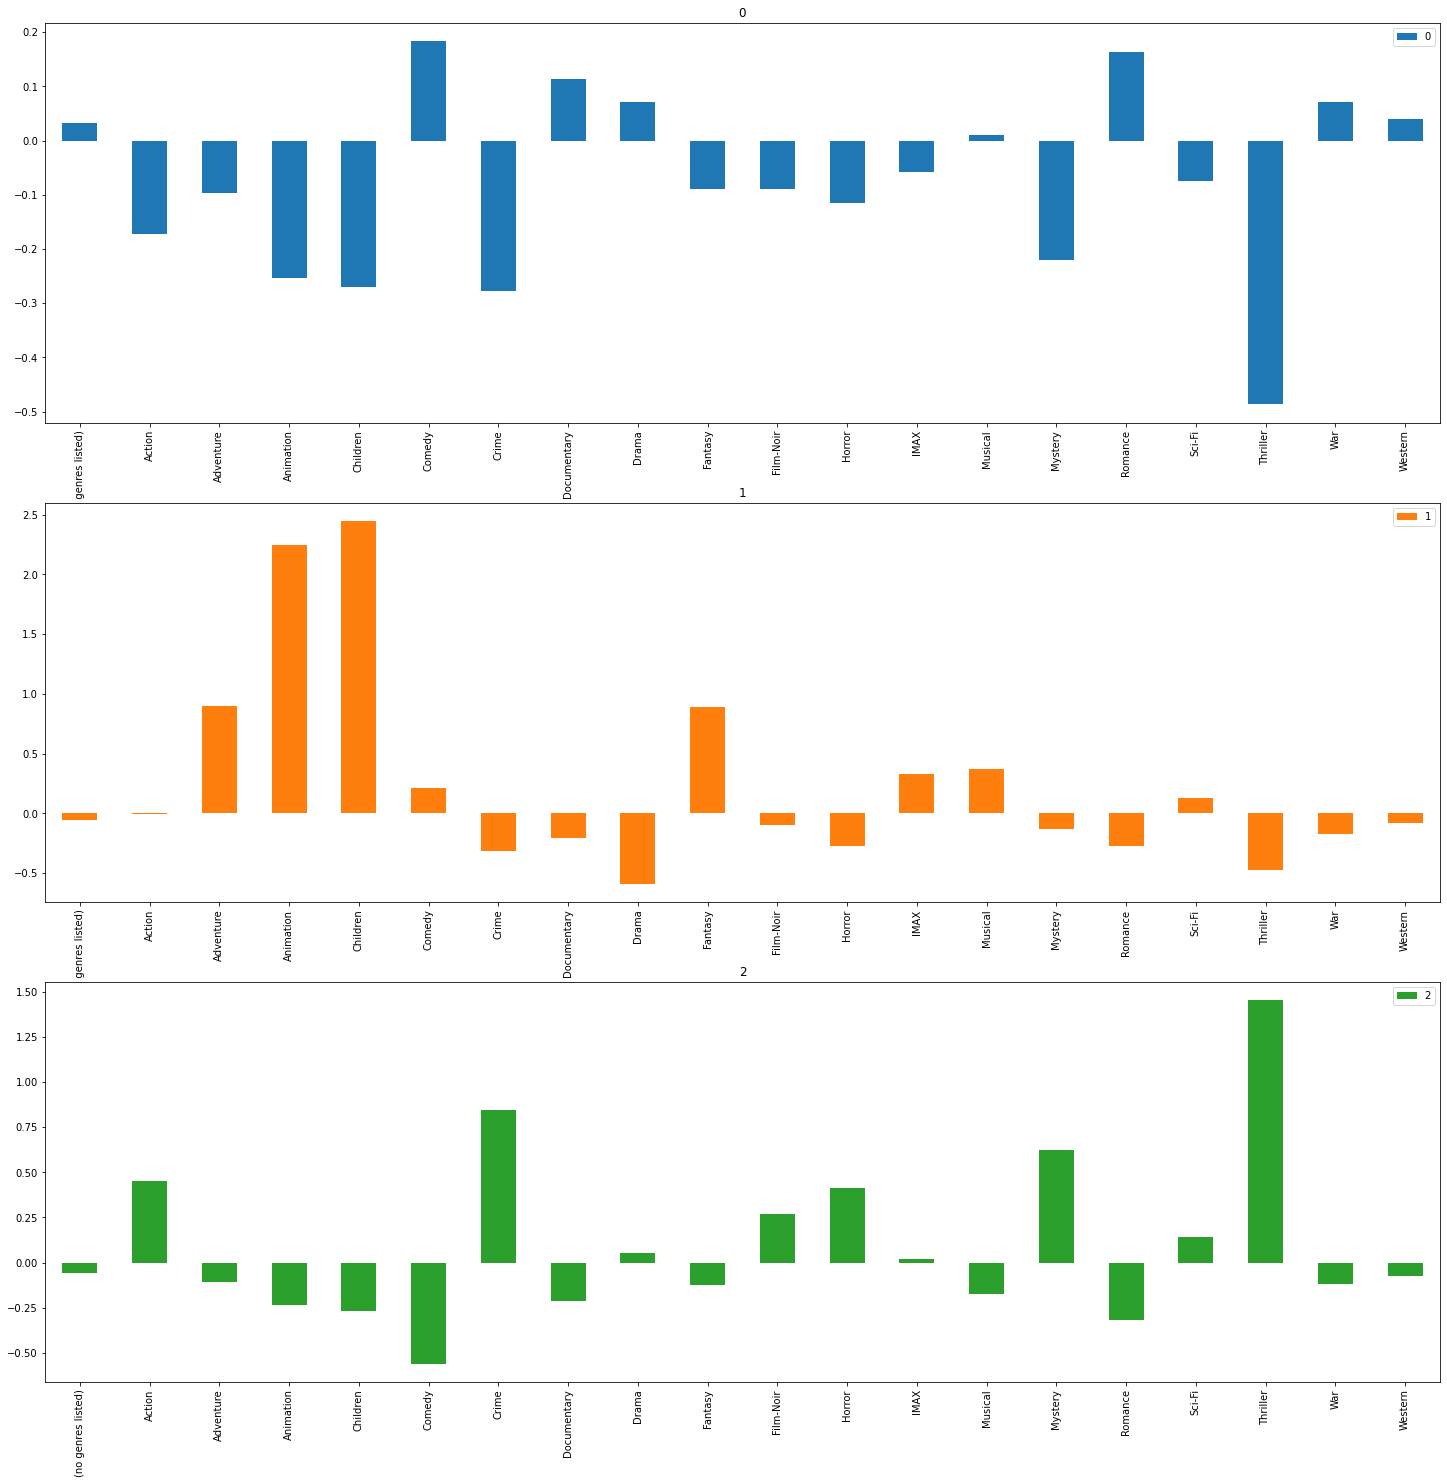

In [9]:
grupos.transpose().plot.bar(subplots=True,
               figsize=(25, 25),
               sharex=False)

In [10]:
grupo = 0

filtro = modelo.labels_ == grupo

dados_dos_filmes[filtro].sample(10)

,filme_id,titulo,generos,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
8577,116963,Ski School (1991),Comedy,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3605,4952,Morons From Outer Space (1985),Comedy|Sci-Fi,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
9404,164909,La La Land (2016),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4543,6748,"Brood, The (1979)",Horror,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1551,2088,Popeye (1980),Adventure|Comedy|Musical,0,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1745,2340,Meet Joe Black (1998),Romance,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2466,3283,Minnie and Moskowitz (1971),Action,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
904,1202,Withnail & I (1987),Comedy,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5198,8462,Executive Suite (1954),Drama,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4855,7258,"Perfect Score, The (2004)",Comedy|Crime,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


In [11]:
from sklearn.manifold import TSNE

In [12]:
tsne = TSNE()

visualizacao = tsne.fit_transform(generos_escalados)
visualizacao

C:\Users\DionizVF\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DionizVF\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


array([[-28.540968 ,  58.057076 ],
       [ 48.124268 ,   7.0806665],
       [  5.7345247, -35.918636 ],
       ...,
       [ -8.6807995,  18.237915 ],
       [-53.612167 ,  18.476254 ],
       [ 27.45691  , -12.365165 ]], dtype=float32)

<AxesSubplot:>

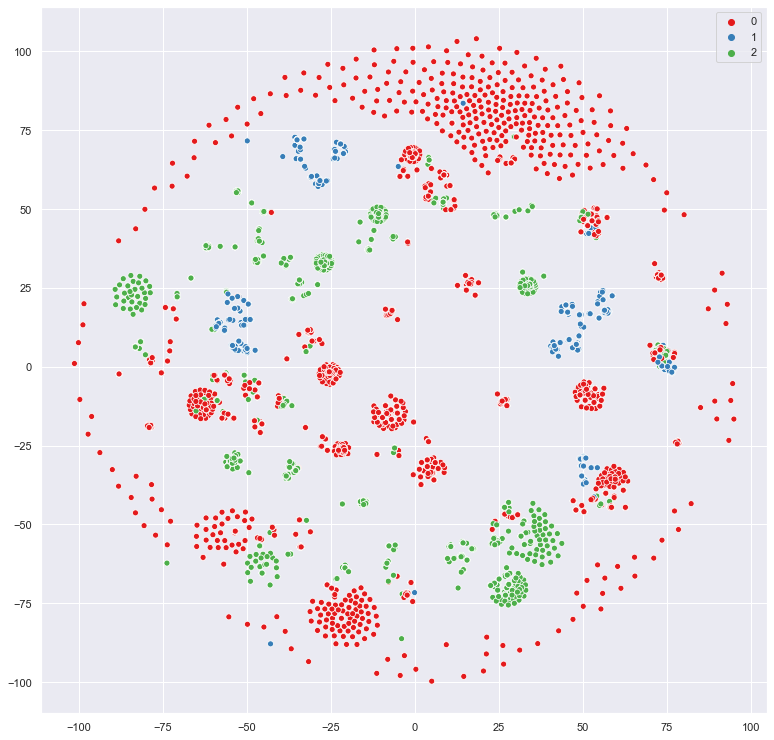

In [13]:
import seaborn as sns

sns.set(rc={'figure.figsize': (13, 13)})



sns.scatterplot(x=visualizacao[:, 0],
               y=visualizacao[:, 1],
               hue=modelo.labels_,
               palette=sns.color_palette('Set1', 3))

array([<AxesSubplot:title={'center':'0'}>,
       <AxesSubplot:title={'center':'1'}>,
       <AxesSubplot:title={'center':'2'}>,
       <AxesSubplot:title={'center':'3'}>,
       <AxesSubplot:title={'center':'4'}>,
       <AxesSubplot:title={'center':'5'}>,
       <AxesSubplot:title={'center':'6'}>,
       <AxesSubplot:title={'center':'7'}>,
       <AxesSubplot:title={'center':'8'}>,
       <AxesSubplot:title={'center':'9'}>,
       <AxesSubplot:title={'center':'10'}>,
       <AxesSubplot:title={'center':'11'}>,
       <AxesSubplot:title={'center':'12'}>,
       <AxesSubplot:title={'center':'13'}>,
       <AxesSubplot:title={'center':'14'}>,
       <AxesSubplot:title={'center':'15'}>,
       <AxesSubplot:title={'center':'16'}>,
       <AxesSubplot:title={'center':'17'}>,
       <AxesSubplot:title={'center':'18'}>,
       <AxesSubplot:title={'center':'19'}>], dtype=object)

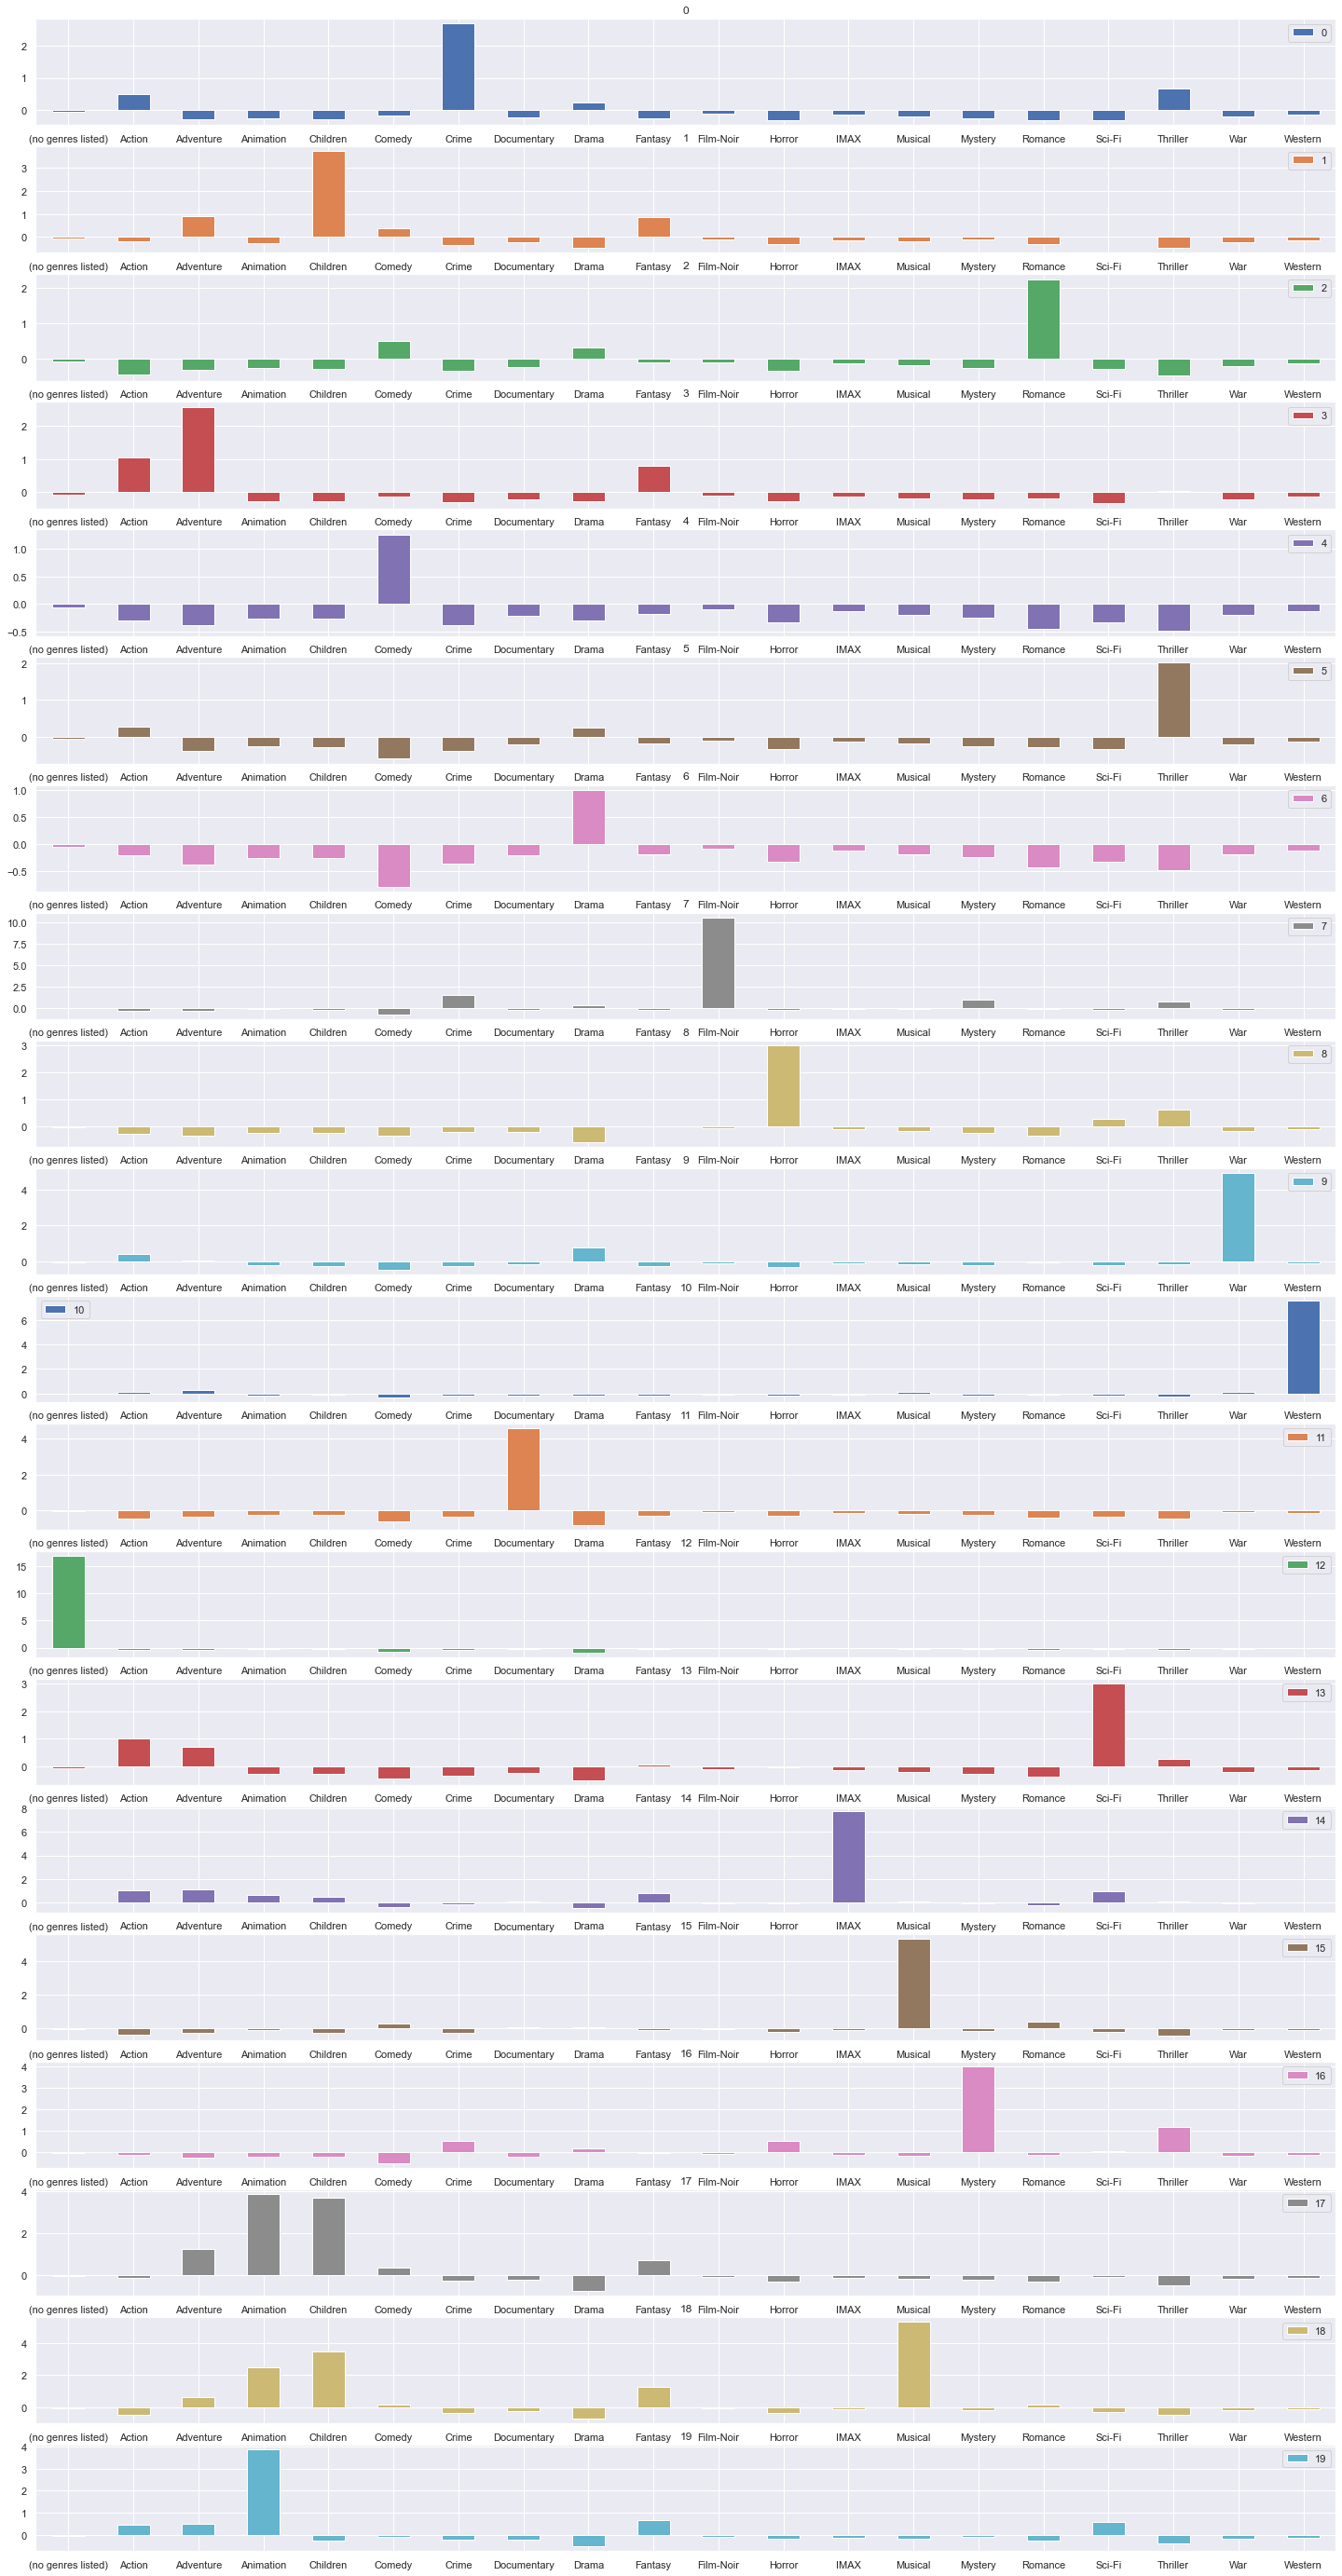

In [14]:
modelo = KMeans(n_clusters=20)

modelo.fit(generos_escalados)

grupos = pd.DataFrame(modelo.cluster_centers_,
            columns=generos.columns)

grupos.transpose().plot.bar(subplots=True,
               figsize=(25, 50),
               sharex=False,
               rot=0)

In [15]:
grupo = 2

filtro = modelo.labels_ == grupo

dados_dos_filmes[filtro].sample(10)

,filme_id,titulo,generos,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
2336,3094,Maurice (1987),Drama|Romance,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4678,6986,Ben-Hur: A Tale of the Christ (1925),Adventure|Drama|Romance,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4497,6658,10 (1979),Comedy|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2228,2962,Fever Pitch (1997),Comedy|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
6090,42007,Rumor Has It... (2005),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4182,6027,Dogfight (1991),Drama|Romance,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
8567,116724,You Are the Apple of My Eye (2011),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2605,3481,High Fidelity (2000),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4150,5970,My Girl (1991),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3055,4091,Can't Buy Me Love (1987),Comedy|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [16]:
def kmeans(numero_de_clusters, generos):
  modelo = KMeans(n_clusters=numero_de_clusters)
  modelo.fit(generos)
  return [numero_de_clusters, modelo.inertia_]

In [17]:
kmeans(20, generos_escalados)

[20, 55188.248819055276]

In [18]:
kmeans(3, generos_escalados)

[3, 166184.80930010474]

In [19]:
resultado = [kmeans(numero_de_grupos, generos_escalados) for numero_de_grupos in range(1, 41)]
resultado

[[1, 194840.00000000274],
 [2, 179483.9402940401],
 [3, 166514.72697362248],
 [4, 156424.33894522744],
 [5, 146919.49034045436],
 [6, 138027.28563217013],
 [7, 128323.3520163103],
 [8, 118958.43896087262],
 [9, 109467.65892404708],
 [10, 103520.35770964916],
 [11, 95207.40364532942],
 [12, 86709.58594779363],
 [13, 78738.0049633102],
 [14, 73469.12256340394],
 [15, 71330.85457996646],
 [16, 65627.49471965642],
 [17, 61752.41136546326],
 [18, 58912.73414774495],
 [19, 56353.82685679025],
 [20, 55674.881518467424],
 [21, 54372.999001797034],
 [22, 52040.571698869346],
 [23, 51775.1458086585],
 [24, 49382.702998099405],
 [25, 48238.63642297327],
 [26, 48006.49225691816],
 [27, 46453.142134993184],
 [28, 44591.25336601724],
 [29, 43528.201417963435],
 [30, 43024.60074905802],
 [31, 42452.523815198816],
 [32, 40667.106067083674],
 [33, 39545.68799758484],
 [34, 39467.2380161217],
 [35, 38509.9693451407],
 [36, 38635.020624359095],
 [37, 37229.93547506528],
 [38, 37384.014374073595],
 [39, 3

In [20]:
resultado = pd.DataFrame(resultado, 
            columns=['grupos', 'inertia'])
resultado

,grupos,inertia
0,1,194840.000000
1,2,179483.940294
2,3,166514.726974
3,4,156424.338945
4,5,146919.490340
5,6,138027.285632
6,7,128323.352016
7,8,118958.438961
8,9,109467.658924
9,10,103520.357710


<AxesSubplot:>

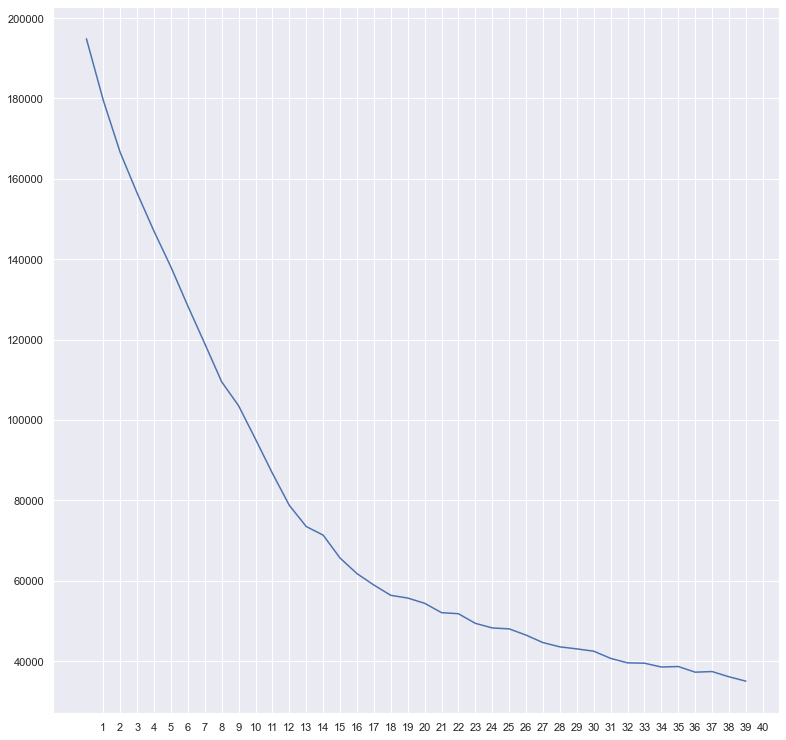

In [21]:
resultado.inertia.plot(xticks=resultado.grupos)

array([<AxesSubplot:title={'center':'0'}>,
       <AxesSubplot:title={'center':'1'}>,
       <AxesSubplot:title={'center':'2'}>,
       <AxesSubplot:title={'center':'3'}>,
       <AxesSubplot:title={'center':'4'}>,
       <AxesSubplot:title={'center':'5'}>,
       <AxesSubplot:title={'center':'6'}>,
       <AxesSubplot:title={'center':'7'}>,
       <AxesSubplot:title={'center':'8'}>,
       <AxesSubplot:title={'center':'9'}>,
       <AxesSubplot:title={'center':'10'}>,
       <AxesSubplot:title={'center':'11'}>,
       <AxesSubplot:title={'center':'12'}>,
       <AxesSubplot:title={'center':'13'}>,
       <AxesSubplot:title={'center':'14'}>,
       <AxesSubplot:title={'center':'15'}>,
       <AxesSubplot:title={'center':'16'}>], dtype=object)

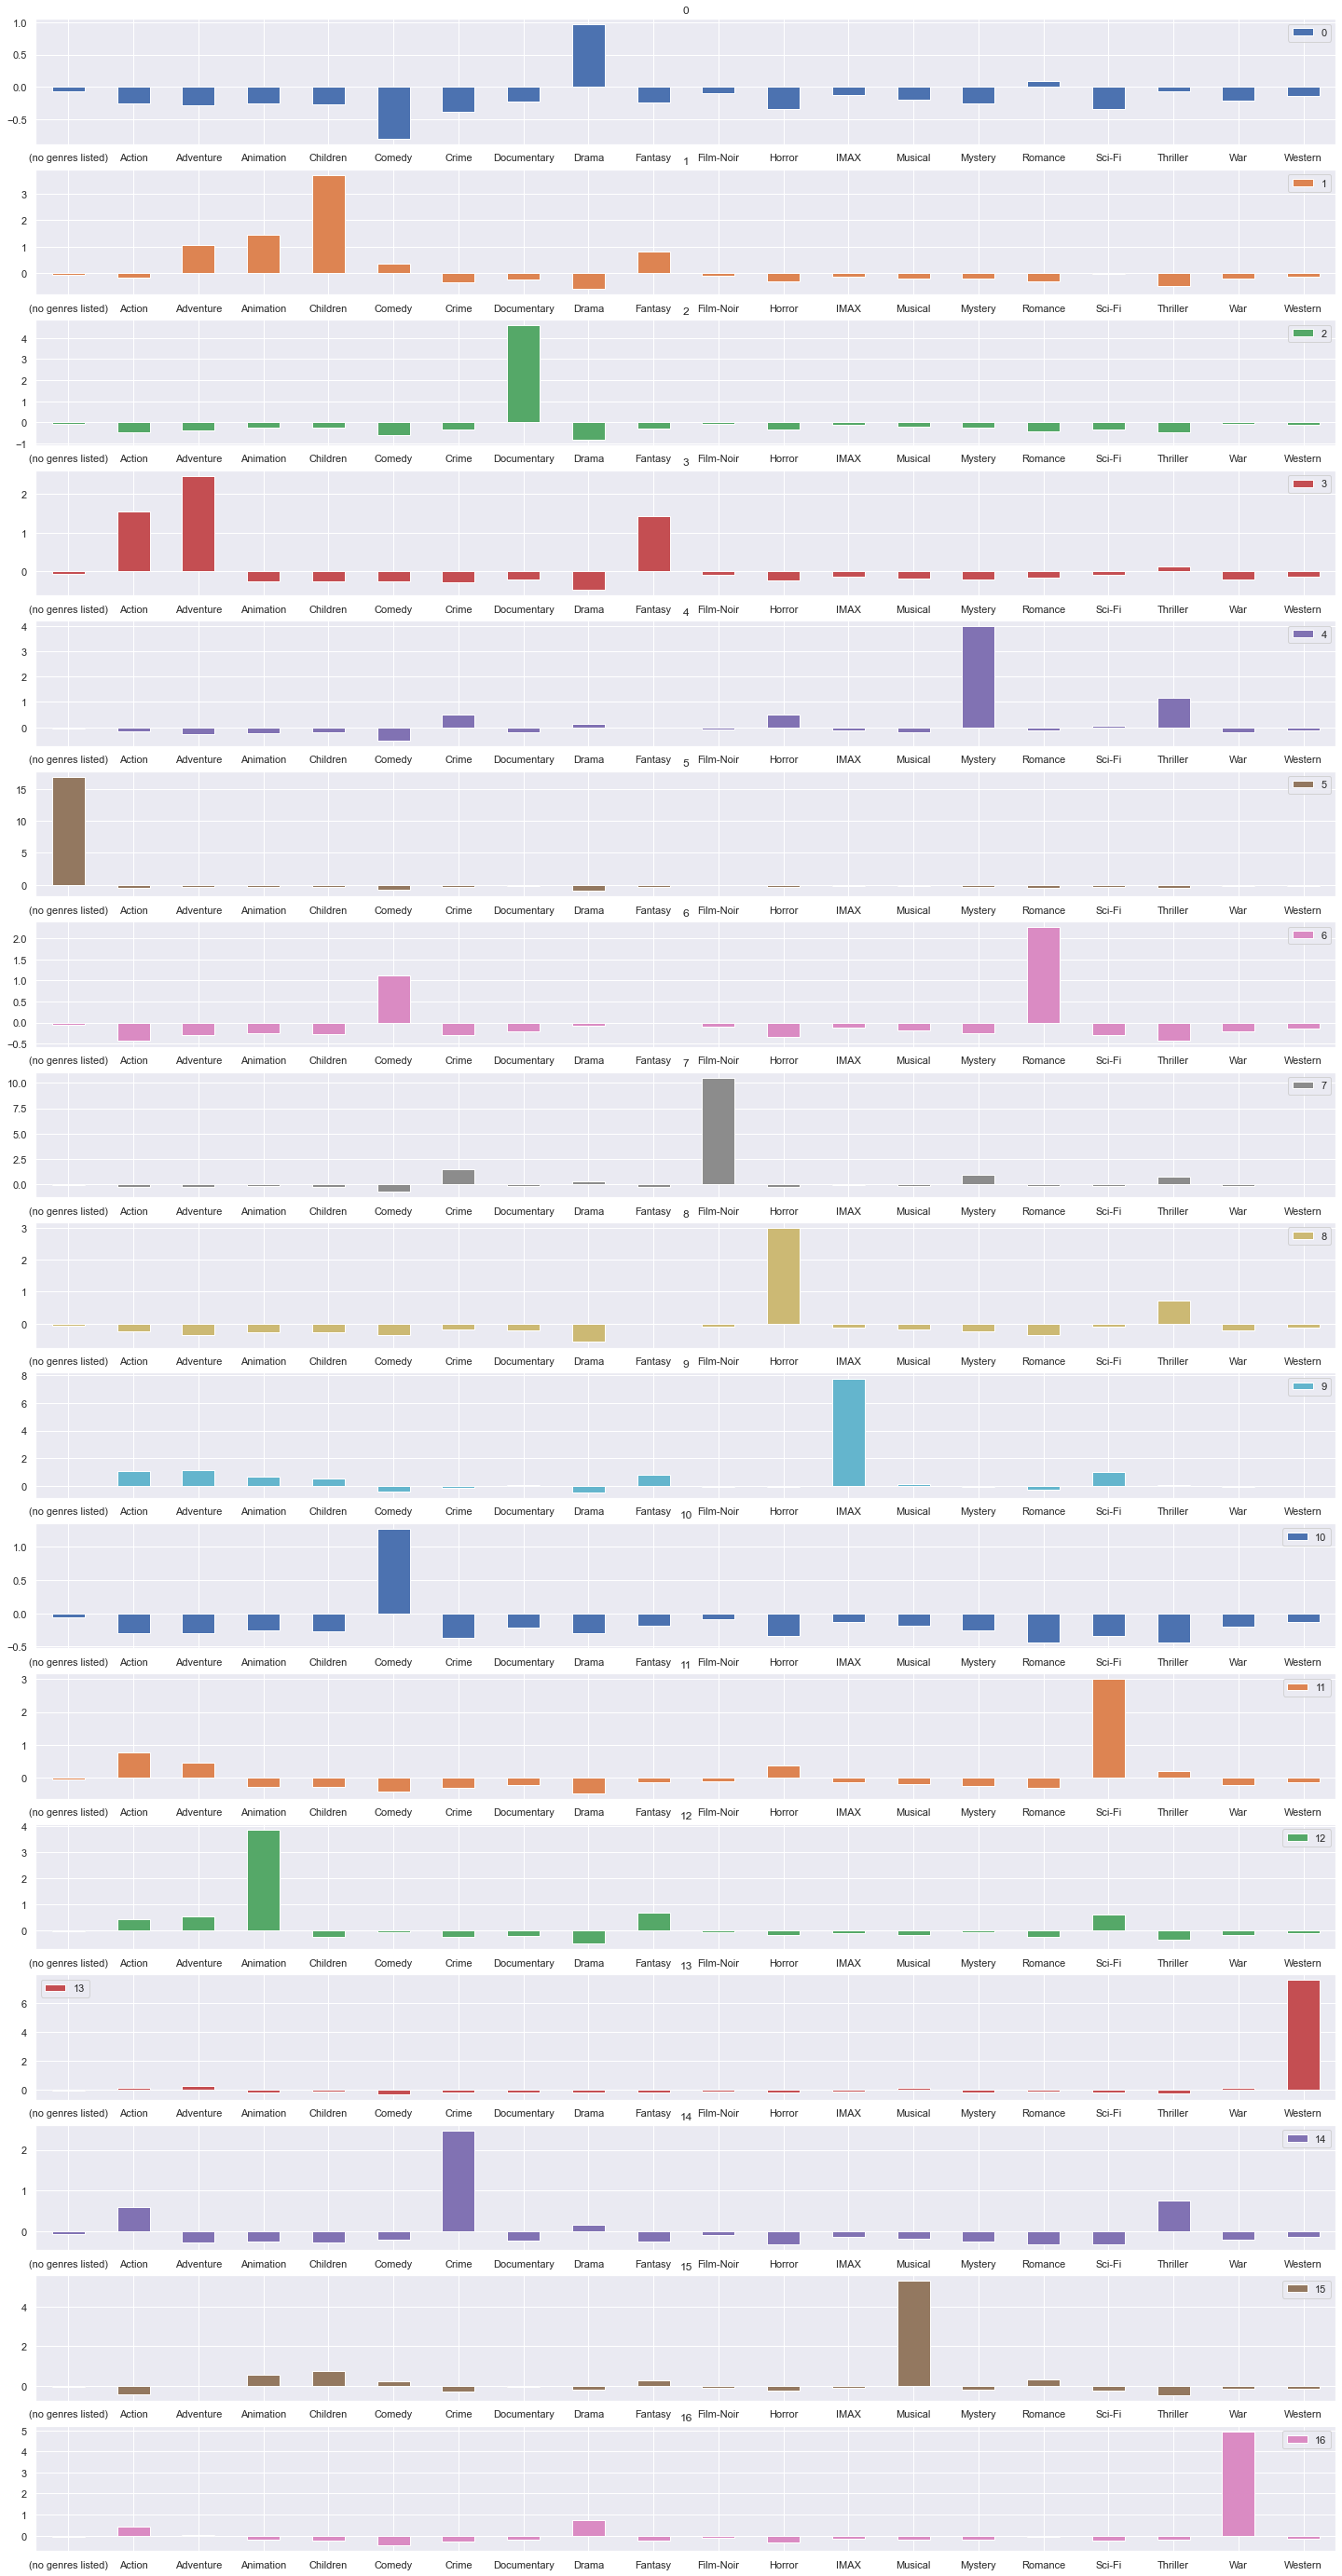

In [22]:
modelo = KMeans(n_clusters=17)
modelo.fit(generos_escalados)

grupos = pd.DataFrame(modelo.cluster_centers_,
            columns=generos.columns)

grupos.transpose().plot.bar(subplots=True,
               figsize=(25, 50),
               sharex=False,
               rot=0)

In [23]:
grupo = 16

filtro = modelo.labels_ == grupo

dados_dos_filmes[filtro].sample(10)

,filme_id,titulo,generos,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
3978,5611,"Four Feathers, The (2002)",Adventure|War,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
5570,26764,Captain America (1990),Action|Fantasy|Sci-Fi|Thriller|War,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,0
6296,48032,"Tiger and the Snow, The (La tigre e la neve) (...",Comedy|Drama|Romance|War,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0
6649,56788,Charlie Wilson's War (2007),Comedy|Drama|War,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
1149,1507,Paradise Road (1997),Drama|War,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
7646,88140,Captain America: The First Avenger (2011),Action|Adventure|Sci-Fi|Thriller|War,0,1,1,0,0,0,0,...,0,0,0,0,0,0,1,1,1,0
6363,49688,"Dam Busters, The (1955)",Action|Drama|War,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2121,2818,Iron Eagle IV (1995),Action|War,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1252,1663,Stripes (1981),Comedy|War,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
7162,71810,Legionnaire (1998),Action|Adventure|Drama|War,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [24]:
from sklearn.cluster import AgglomerativeClustering

In [25]:
modelo = AgglomerativeClustering(n_clusters=17)
grupos = modelo.fit_predict(generos_escalados)
grupos

array([ 5, 14, 13, ...,  2,  5,  3], dtype=int64)

In [26]:
tsne = TSNE()
visualizacao = tsne.fit_transform(generos_escalados)
visualizacao

C:\Users\DionizVF\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DionizVF\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


array([[-12.60255  , -50.614494 ],
       [-53.31681  , -19.179222 ],
       [ 22.141228 ,  14.656089 ],
       ...,
       [  8.035049 , -30.946844 ],
       [-21.137247 , -27.54895  ],
       [ -1.9574732,  22.917147 ]], dtype=float32)

<AxesSubplot:>

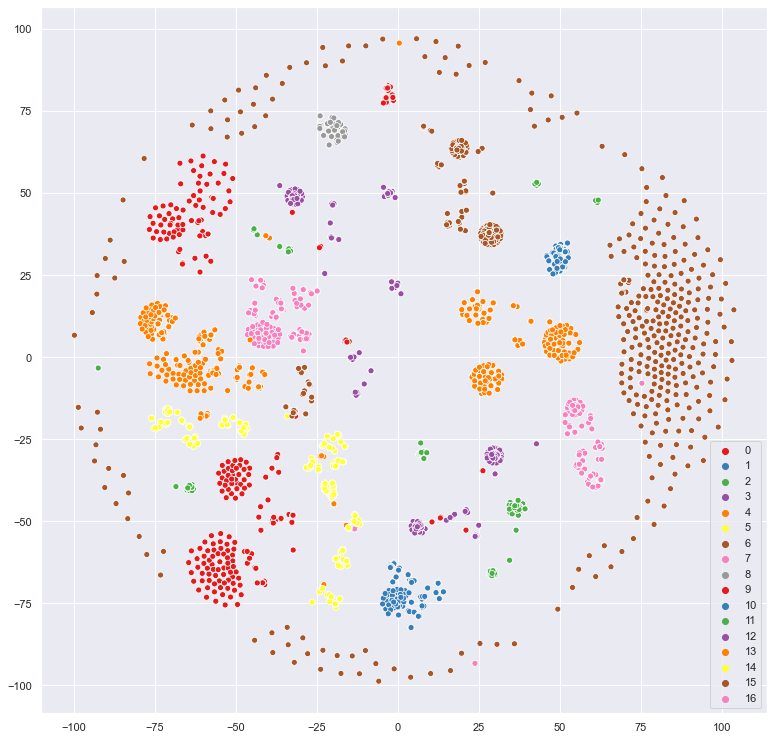

In [27]:
sns.scatterplot(x=visualizacao[:, 0],
                y=visualizacao[:, 1],
                hue=grupos,
                palette = sns.color_palette('Set1', 17))

In [28]:
from scipy.cluster.hierarchy import dendrogram, linkage

array([<AxesSubplot:title={'center':'0'}>,
       <AxesSubplot:title={'center':'1'}>,
       <AxesSubplot:title={'center':'2'}>,
       <AxesSubplot:title={'center':'3'}>,
       <AxesSubplot:title={'center':'4'}>,
       <AxesSubplot:title={'center':'5'}>,
       <AxesSubplot:title={'center':'6'}>,
       <AxesSubplot:title={'center':'7'}>,
       <AxesSubplot:title={'center':'8'}>,
       <AxesSubplot:title={'center':'9'}>,
       <AxesSubplot:title={'center':'10'}>,
       <AxesSubplot:title={'center':'11'}>,
       <AxesSubplot:title={'center':'12'}>,
       <AxesSubplot:title={'center':'13'}>,
       <AxesSubplot:title={'center':'14'}>,
       <AxesSubplot:title={'center':'15'}>,
       <AxesSubplot:title={'center':'16'}>], dtype=object)

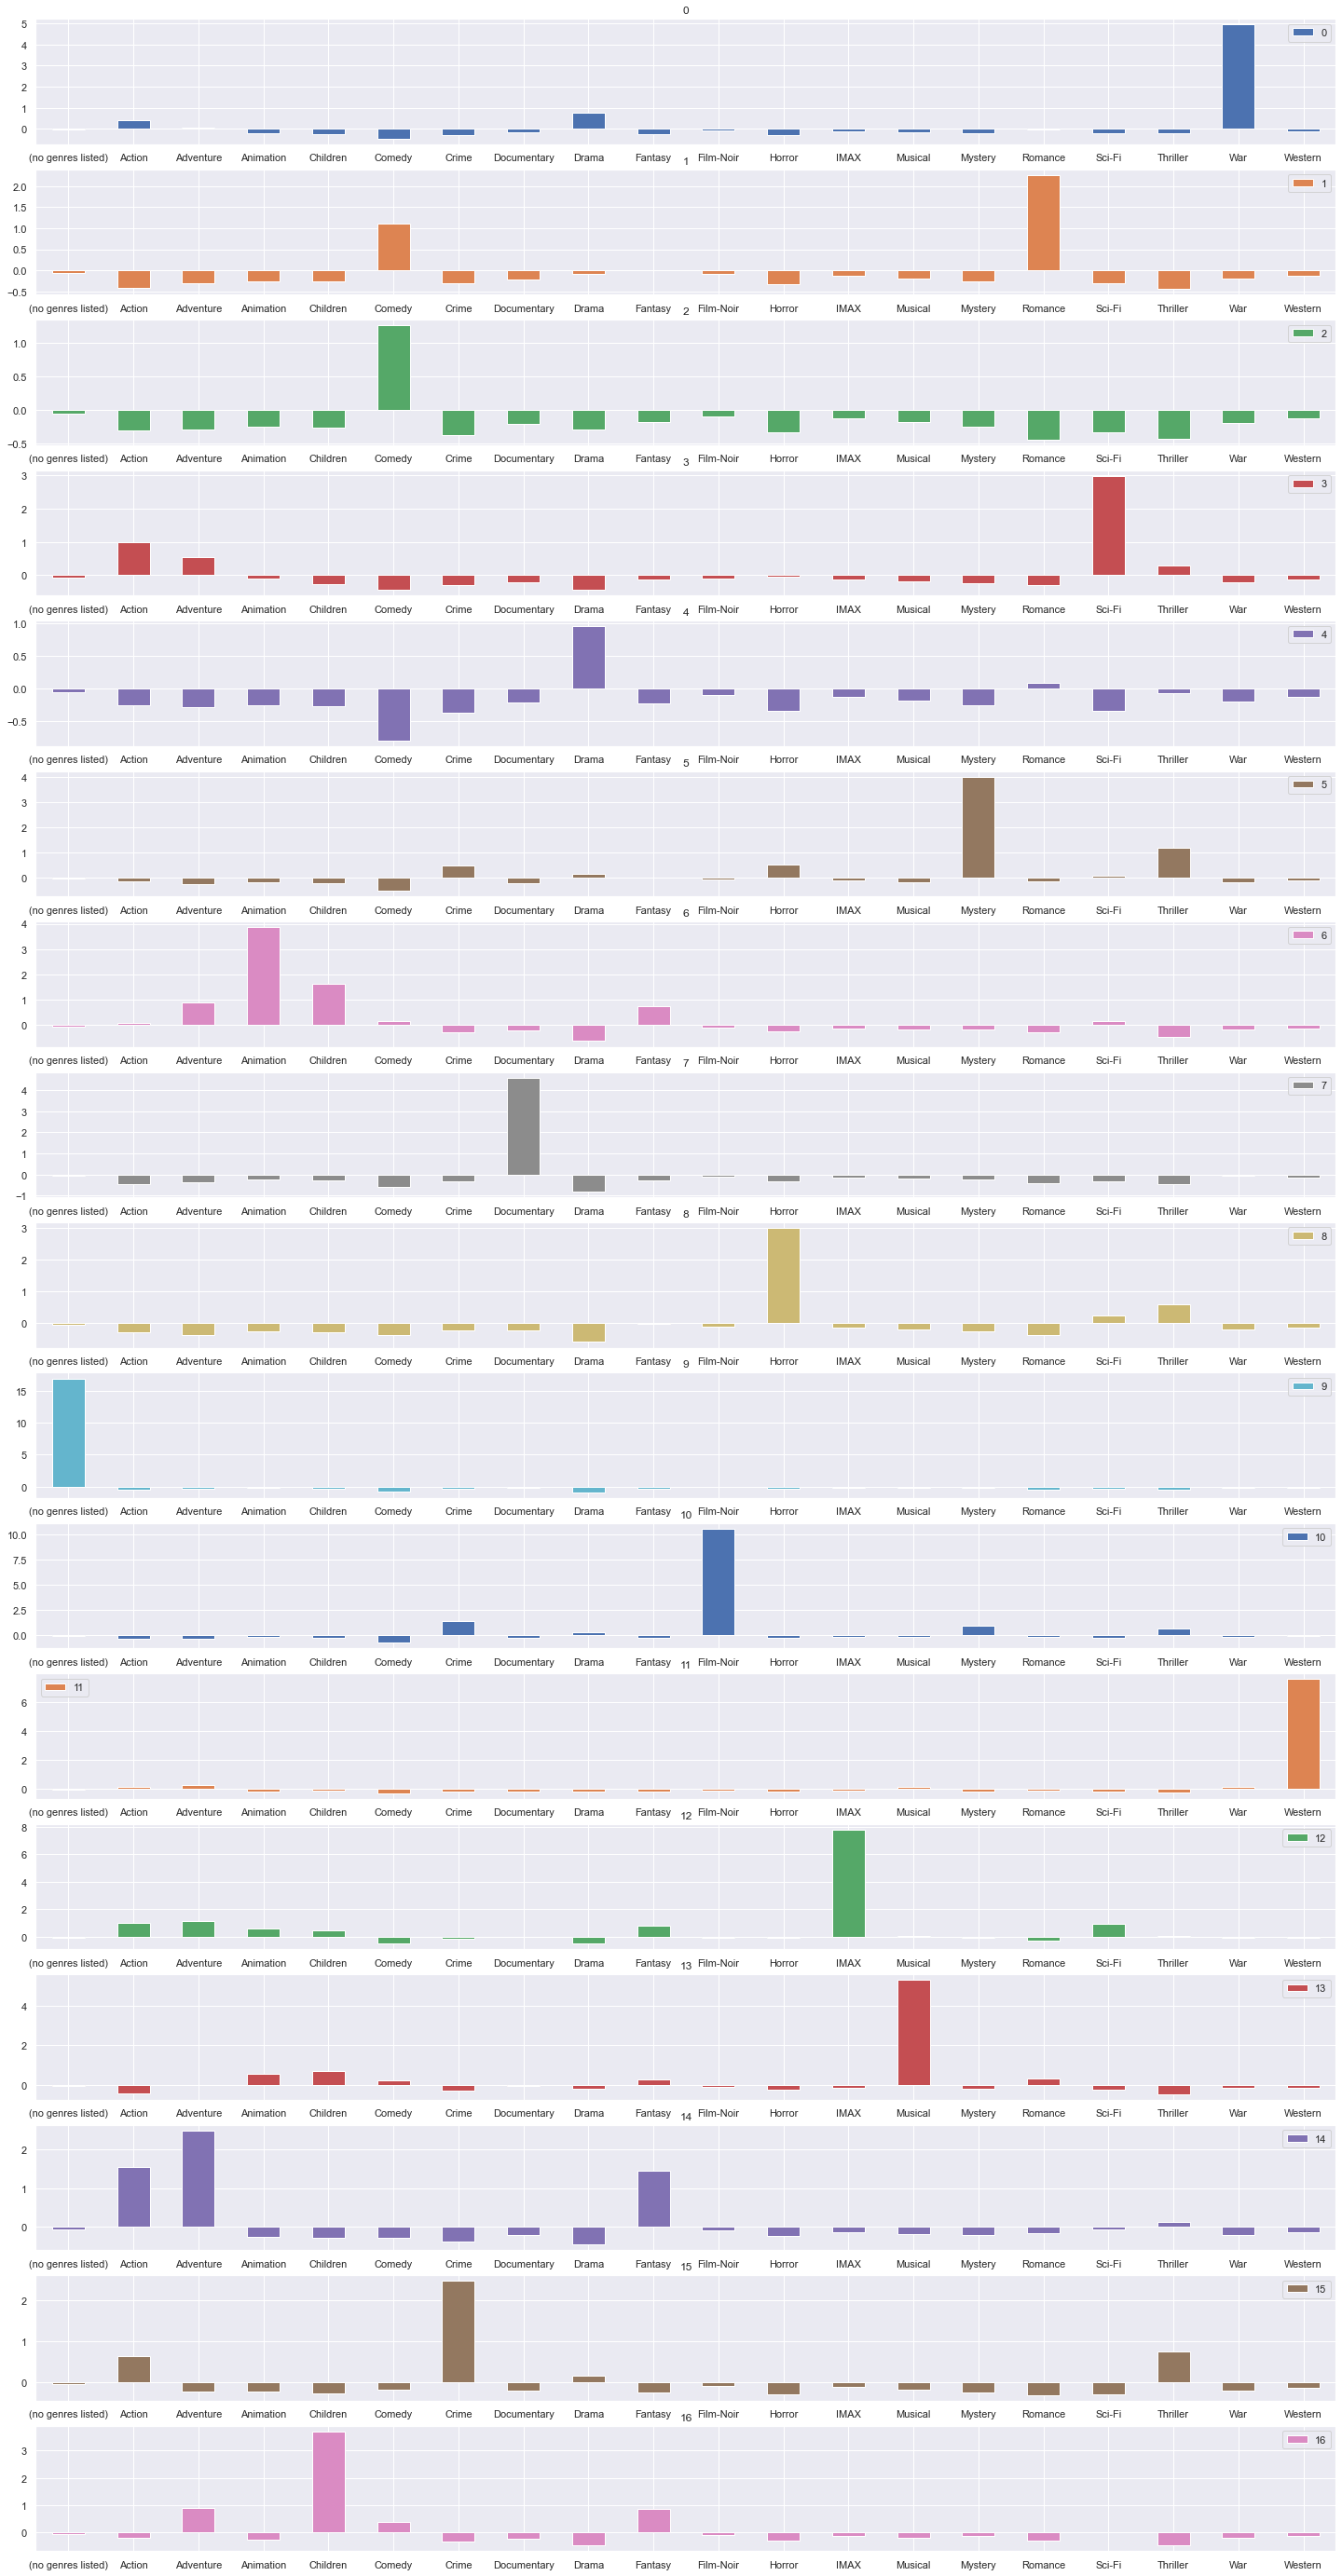

In [29]:
modelo = KMeans(n_clusters=17)
modelo.fit(generos_escalados)

grupos = pd.DataFrame(modelo.cluster_centers_,
            columns=generos.columns)

grupos.transpose().plot.bar(subplots=True,
               figsize=(25, 50),
               sharex=False,
               rot=0)

In [30]:
matriz_de_distancia = linkage(grupos)
matriz_de_distancia

array([[ 2.        ,  4.        ,  2.49504192,  2.        ],
       [ 1.        , 17.        ,  2.72358726,  3.        ],
       [15.        , 18.        ,  3.27829572,  4.        ],
       [ 8.        , 19.        ,  3.8330892 ,  5.        ],
       [ 3.        , 20.        ,  3.97382959,  6.        ],
       [14.        , 21.        ,  4.00622873,  7.        ],
       [16.        , 22.        ,  4.38647834,  8.        ],
       [ 6.        , 23.        ,  4.64180949,  9.        ],
       [ 5.        , 24.        ,  4.69977924, 10.        ],
       [ 7.        , 25.        ,  5.18242009, 11.        ],
       [ 0.        , 26.        ,  5.22337067, 12.        ],
       [13.        , 27.        ,  5.81773336, 13.        ],
       [11.        , 28.        ,  7.85706787, 14.        ],
       [12.        , 29.        ,  8.24414926, 15.        ],
       [10.        , 30.        , 10.80329026, 16.        ],
       [ 9.        , 31.        , 17.07392674, 17.        ]])

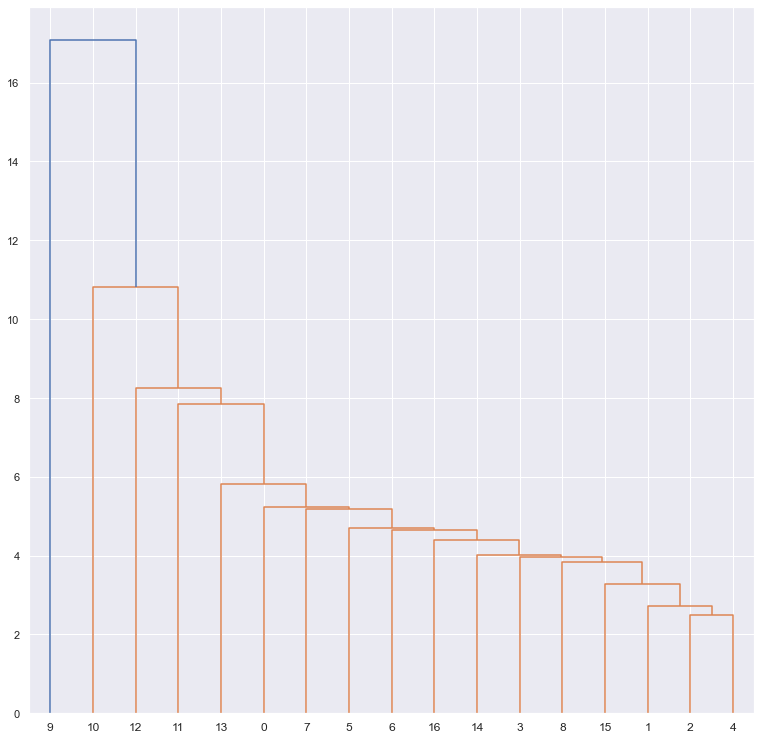

In [31]:
dendrograma = dendrogram(matriz_de_distancia)